In [1]:
from google.colab import files
upl=files.upload()

Saving telechurn.csv to telechurn.csv


In [2]:
import numpy as np
import pandas as pd

In [164]:
df=pd.read_csv("telechurn.csv")

In [165]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [166]:
df.drop(columns="customerID",inplace=True)

In [167]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [169]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [170]:
df["Churn"].unique()

array(['No', 'Yes'], dtype=object)

In [171]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [172]:
df["Churn"].unique()

array([0, 1])

In [173]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [174]:
df["TotalCharges"].dtype

dtype('float64')

In [175]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
import shap

In [176]:
nominal_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling",
    "PaymentMethod"
]

ordinal_cols = [
    "Contract"
]

numeric_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]


In [177]:
cat_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

ord_pipeline = Pipeline([
    ("ordinal", OrdinalEncoder(
        categories=[
            ["Month-to-month", "One year", "Two year"]
        ]
    ))
])

In [178]:
preprocessor = ColumnTransformer([
    ("cat", cat_pipeline, nominal_cols),
    ("ord", ord_pipeline, ordinal_cols),
    ("num", StandardScaler(), numeric_cols)
], remainder="passthrough")

In [179]:
pipeline=Pipeline([
    ("prep",preprocessor),
    ("model",XGBClassifier())
])

In [180]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV

In [181]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [183]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
    shuffle=True
)

In [184]:
y

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [185]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 19)
(1409, 19)
(5634,)
(1409,)


In [186]:
params_grid_xg=[
    {

        'model__n_estimators': range(100, 250, 10),
        'model__max_depth': range(3, 15,1),
        'model__learning_rate': np.linspace(0.01, 0.1, 20),

        'model__subsample': np.linspace(0.2, 1, 8),
        'model__reg_lambda': np.linspace(0.01, 0.8, 20),
        'model__colsample_bytree': np.linspace(0.1, 1, 10),
        'model__reg_alpha':np.linspace(0.01, 0.8, 20)

    }
]

In [187]:
grid_xgboost = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=params_grid_xg,
    cv=5,
    n_jobs=-1,
    scoring='f1_macro'
)

In [188]:
print("start")
best_estimator_xgboost=grid_xgboost.fit(x_train,y_train)
print("done")

start
done


In [189]:
best_estimator_xgboost

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('prep',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               Pipeline(steps=[('onehot',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['gender',
                                                                                'Partner',
                                                                                'Dependents',
                                                                                'PhoneService',
                                                                                'MultipleLines',
                                                                                'InternetService',
                                                                                'OnlineSecurity',
                                                                                'OnlineBackup',
                                                                                'DeviceProtection',
                                                                                'TechSupport',
                                                                                'StreamingTV',...
                                         'model__reg_lambda': array([0.01      , 0.05157895, 0.09315789, 0.13473684, 0.17631579,
       0.21789474, 0.25947368, 0.30105263, 0.34263158, 0.38421053,
       0.42578947, 0.46736842, 0.50894737, 0.55052632, 0.59210526,
       0.63368421, 0.67526316, 0.71684211, 0.75842105, 0.8       ]),
                                         'model__subsample': array([0.2       , 0.31428571, 0.42857143, 0.54285714, 0.65714286,
       0.77142857, 0.88571429, 1.        ])}],
                   scoring='f1_macro')

In [192]:
best_pipeline = grid_xgboost.best_estimator_

In [193]:
preprocessor_fitted = best_pipeline.named_steps["prep"]

In [194]:
X_test_transformed = preprocessor_fitted.transform(x_test)

print(X_test_transformed.shape)

(1409, 43)


In [195]:
xgb_model = best_pipeline.named_steps["model"]

In [196]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(
    X_test_transformed
)

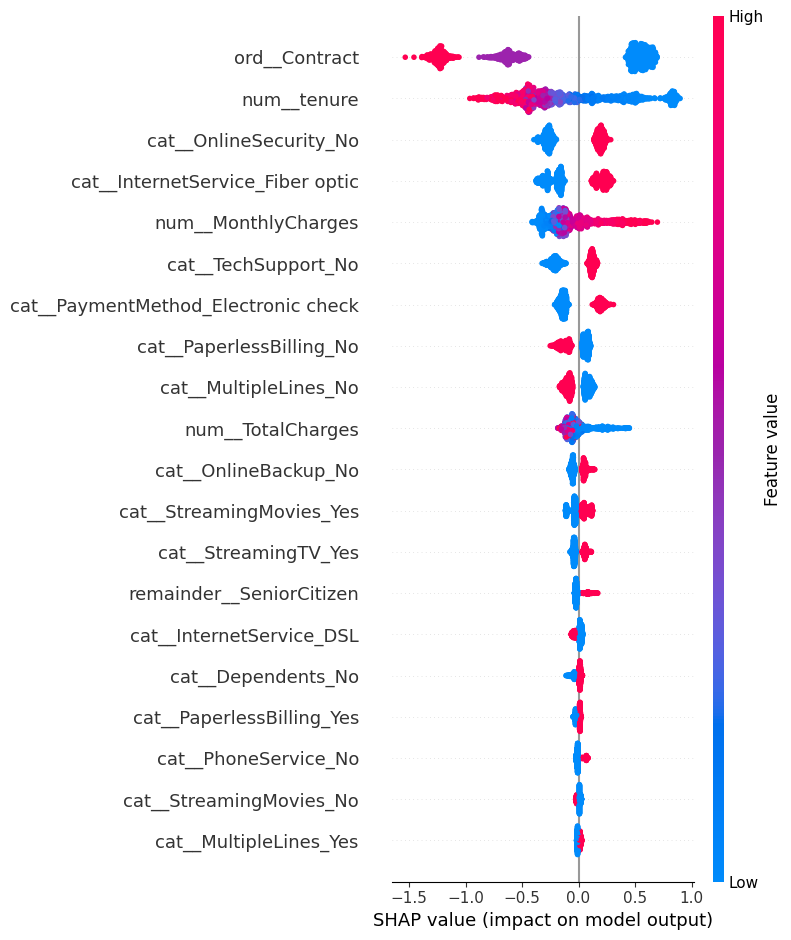

In [206]:
feature_names = preprocessor_fitted.get_feature_names_out()

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.show()

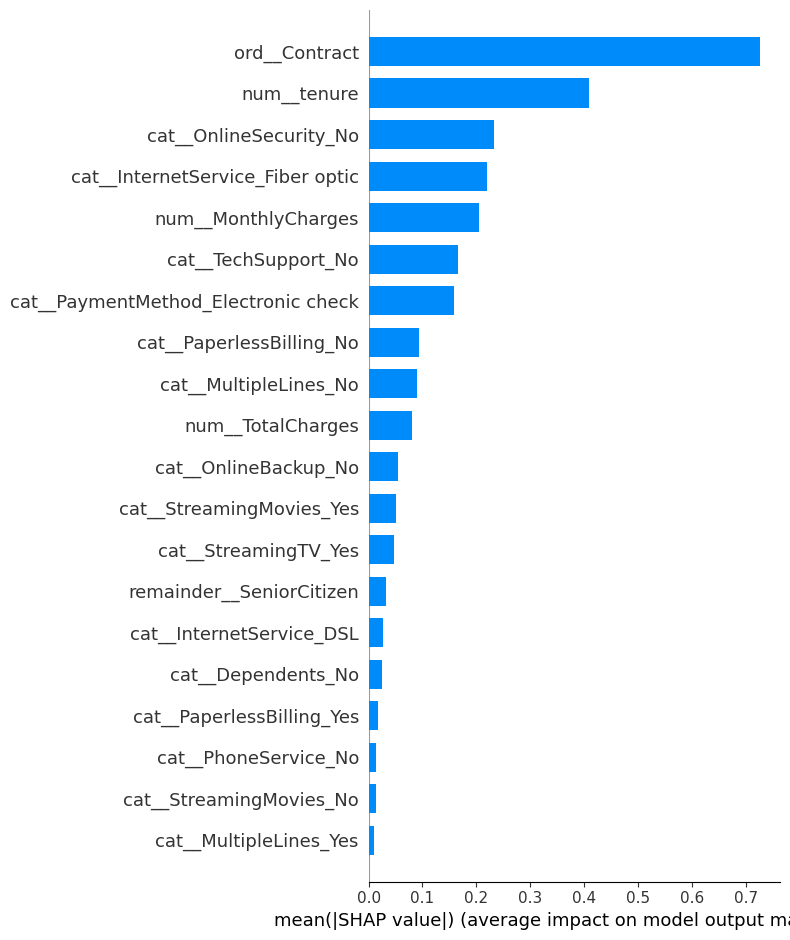

<Figure size 640x480 with 0 Axes>

In [207]:
feature_names = preprocessor_fitted.get_feature_names_out()

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar")

plt.tight_layout()
plt.show()